# Laboratorio 4 — Agrupación: VuelaAlpes 
#TODO
Cambiar: Recomendación de Planes de Entrenamiento y Nutrición

**Curso:** ISIS2611 — Aprendizaje de Máquina  
**Fecha:** 11 de mayo de 2026  
**Integrantes:**
- Cristian Felipe Ochoa Osorio 
- Ana Sofía Padilla Daza  

---

### Descripción
#TODO
Cambiar: SmartAlpes requiere automatizar la recomendación de planes personalizados de entrenamiento y nutrición a partir del perfil físico, hábitos y estilo de vida de sus clientes. Se construyen modelos de clasificación multiclase (4 clases en cada objetivo) usando Regresión Logística y Árboles de Decisión, con búsqueda de hiperparámetros y validación cruzada estratificada.

**Actividades:**
1. Exploración y limpieza de datos
2. Algoritmo de agrupación 1
3. Algoritmo de agrupación 2
4. Algoritmo de agrupación 3 
5. Tabla comparativa y selección del mejor modelo
5. Evaluación cualitativa e interpretación de los grupos
6. Análisis de resultados
7. Uso de IAG 
8. Video explicativo

# Falta por hacer
[ ] Limpieza de datos

[ ] Algo 1

[ ] Algo 2

[ ] Algo 3

[ ] Tabla

[ ] Evaluacion cualitativa

[ ] Respuesta preguntas

[ ] Uso de IAG

[ ] Video

## Librerías

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, hamming_loss
)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Configuración global ───────────────────────────────────────────
RANDOM_STATE = 42
N_JOBS       = -1
CV_FOLDS     = 5
TEST_SIZE    = 0.20
DATA_PATH    = './Datos_VuelaAlpes.csv'

np.random.seed(RANDOM_STATE)

# Diccionario para almacenar resultados comparativos
resultados = {}

# Crear carpeta predictions si no existe
os.makedirs('./predictions', exist_ok=True)

## 1. Exploración de los Datos

Cargamos el dataset e identificamos problemas de calidad antes de cualquier transformación. El separador es `;` y el encoding es `latin-1` (caracteres españoles como `ñ` y tildes).

In [21]:
df = pd.read_csv(DATA_PATH, sep=';', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumnas:")
print(df.dtypes)
print(f"\nPrimeras filas:")
display(df.head(3))

Shape: (9698, 26)

Columnas:
Edad                         int64
Gnereo                      object
Peso                       float64
Altura                     float64
BMI                        float64
Objetivo                    object
Condicion_salud             object
Nivel_Actividad             object
Nivel_experiencia           object
Dieta_preferida             object
Horas_sueño                float64
Entrenamiento_preferido     object
Cantidad_equipo              int64
Tiempo_disponible            int64
Tiene_alergia                int64
Problemas_digestivos         int64
Fumador                      int64
Cigarrillos_dia            float64
Alcohol                      int64
Alcohol_semana             float64
Score_micronutrientes      float64
Ingesta_proteinas          float64
Pasos_dia                    int64
Ingesta_agua               float64
Plan_entrenamiento          object
Plan_nutrición              object
dtype: object

Primeras filas:


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico


In [22]:
print("=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

print("\n=== ESTADÍSTICAS NUMÉRICAS ===")
display(df.describe().round(2))

print("\n=== DISTRIBUCIÓN DE TARGETS ===")
for target in ['Plan_entrenamiento', 'Plan_nutrición']:
    print(f"\n{target}:")
    counts = df[target].value_counts()
    print(counts)
    print(f"  → Clase mayoritaria: {df[target].value_counts(normalize=True).max():.1%}")

=== VALORES NULOS ===
Peso    11
dtype: int64

=== ESTADÍSTICAS NUMÉRICAS ===


,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.00,9687.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.0,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00
mean,45.11,92.62,1.78,30.13,7.00,2.99,67.19,0.2,0.15,0.23,2.17,0.29,3.78,0.50,130.00,9765.94,2.75
std,17.64,27.38,0.16,10.61,1.45,2.02,30.84,0.4,0.36,0.42,4.62,0.45,7.02,0.29,51.98,4762.15,1.02
min,15.00,45.00,1.50,10.93,0.00,0.00,15.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,40.00,200.00,1.00
25%,30.00,68.80,1.64,21.62,5.80,1.00,40.00,0.0,0.00,0.00,0.00,0.00,0.00,0.25,85.00,5608.25,1.86
50%,45.00,92.60,1.78,29.19,7.00,3.00,67.00,0.0,0.00,0.00,0.00,0.00,0.00,0.50,129.95,9718.00,2.76
75%,61.00,116.50,1.91,37.06,8.20,5.00,94.00,0.0,0.00,0.00,0.00,1.00,4.30,0.75,175.20,13953.00,3.62
max,75.00,140.00,2.05,62.09,23.00,6.00,120.00,1.0,1.00,1.00,18.00,1.00,25.00,1.00,220.00,17996.00,4.50



=== DISTRIBUCIÓN DE TARGETS ===

Plan_entrenamiento:
Plan_entrenamiento
Ninguno    3807
Medio      2945
Bajo       2290
Alto        656
Name: count, dtype: int64
  → Clase mayoritaria: 39.3%

Plan_nutrición:
Plan_nutrición
Balanceado       4297
Sin plan         2522
Basico           2287
Especializado     592
Name: count, dtype: int64
  → Clase mayoritaria: 44.3%


In [23]:
# Variables categóricas: verificar valores únicos vs diccionario
cats = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
        'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']

print("=== VALORES ÚNICOS POR VARIABLE CATEGÓRICA ===")
for col in cats:
    vals = sorted(df[col].unique())
    print(f"\n{col} ({len(vals)} valores):\n  {vals}")

=== VALORES ÚNICOS POR VARIABLE CATEGÓRICA ===

Gnereo (3 valores):
  ['Femenino', 'Masculino', 'Otro']

Objetivo (5 valores):
  ['Ganancia muscular', 'General', 'Perdida grasa', 'Resistencia', 'grasa']

Condicion_salud (7 valores):
  ['Asma', 'Diabetes', 'Enfermedad corazon', 'Hipertension', 'Lesion', 'Ninguno', 'PCOS']

Nivel_Actividad (3 valores):
  ['Alto', 'Bajo', 'Moderado']

Nivel_experiencia (3 valores):
  ['Avanzado', 'Intermedio', 'Principiante']

Dieta_preferida (5 valores):
  ['Animal', 'No-Vegetariano', 'Pescetariano', 'Vegano', 'Vegetariano']

Entrenamiento_preferido (6 valores):
  ['Balance', 'Cardio', 'Flexibilidad', 'Fuerza', 'Funcional', 'Hit']


### Propuesta de limpieza

*Problemas de calidad identificados*

| Variable | Problema | Decisión | Justificación |
|---|---|---|---|
| `Objetivo` | Valor `'grasa'` (debería ser `'Perdida grasa'`) | Corregir con `.replace()` | Error tipográfico; misma categoría semántica |
| `Dieta_preferida` | Valor `'Animal'` no está en el diccionario | Reclasificar como `'No-Vegetariano'` | Semánticamente equivalente según dominio |
| `Horas_sueño` | Máximo de 23h (imposible fisiológicamente) | Eliminar filas con > 12h | Un humano no puede dormir más de ~12h/día de forma sostenida |
| `Peso` | 11 valores nulos (0.11%) | Imputar con mediana | La mediana es robusta a la distribución asimétrica de peso |

*Otros problemas:* 
- Desbalance de clases: Alto/Especializado son clases minoritarias (~6-7%).  Usar `class_weight='balanced'` en regresión logística; `class_weight='balanced'` en árboles de decisión lo cual evita sesgo hacia clases mayoritarias

In [24]:
df_clean = df.copy()

# 1. Corregir errores tipográficos
df_clean['Objetivo'] = df_clean['Objetivo'].replace('grasa', 'Perdida grasa')
df_clean['Dieta_preferida'] = df_clean['Dieta_preferida'].replace('Animal', 'No-Vegetariano')

# 2. Eliminar outliers fisiológicamente imposibles
mask_sueño = df_clean['Horas_sueño'] <= 12
print(f"Filas eliminadas por Horas_sueño > 12: {(~mask_sueño).sum()}")
df_clean = df_clean[mask_sueño].reset_index(drop=True)

print(f"\nTamaño antes: {len(df)} | Después: {len(df_clean)}")
print(f"Registros retenidos: {len(df_clean)/len(df):.1%}")

# Verificar correcciones
print(f"\nObjetivo valores únicos: {sorted(df_clean['Objetivo'].unique())}")
print(f"Dieta_preferida valores únicos: {sorted(df_clean['Dieta_preferida'].unique())}")

Filas eliminadas por Horas_sueño > 12: 2

Tamaño antes: 9698 | Después: 9696
Registros retenidos: 100.0%

Objetivo valores únicos: ['Ganancia muscular', 'General', 'Perdida grasa', 'Resistencia']
Dieta_preferida valores únicos: ['No-Vegetariano', 'Pescetariano', 'Vegano', 'Vegetariano']


### Propuesta de preparación de datos

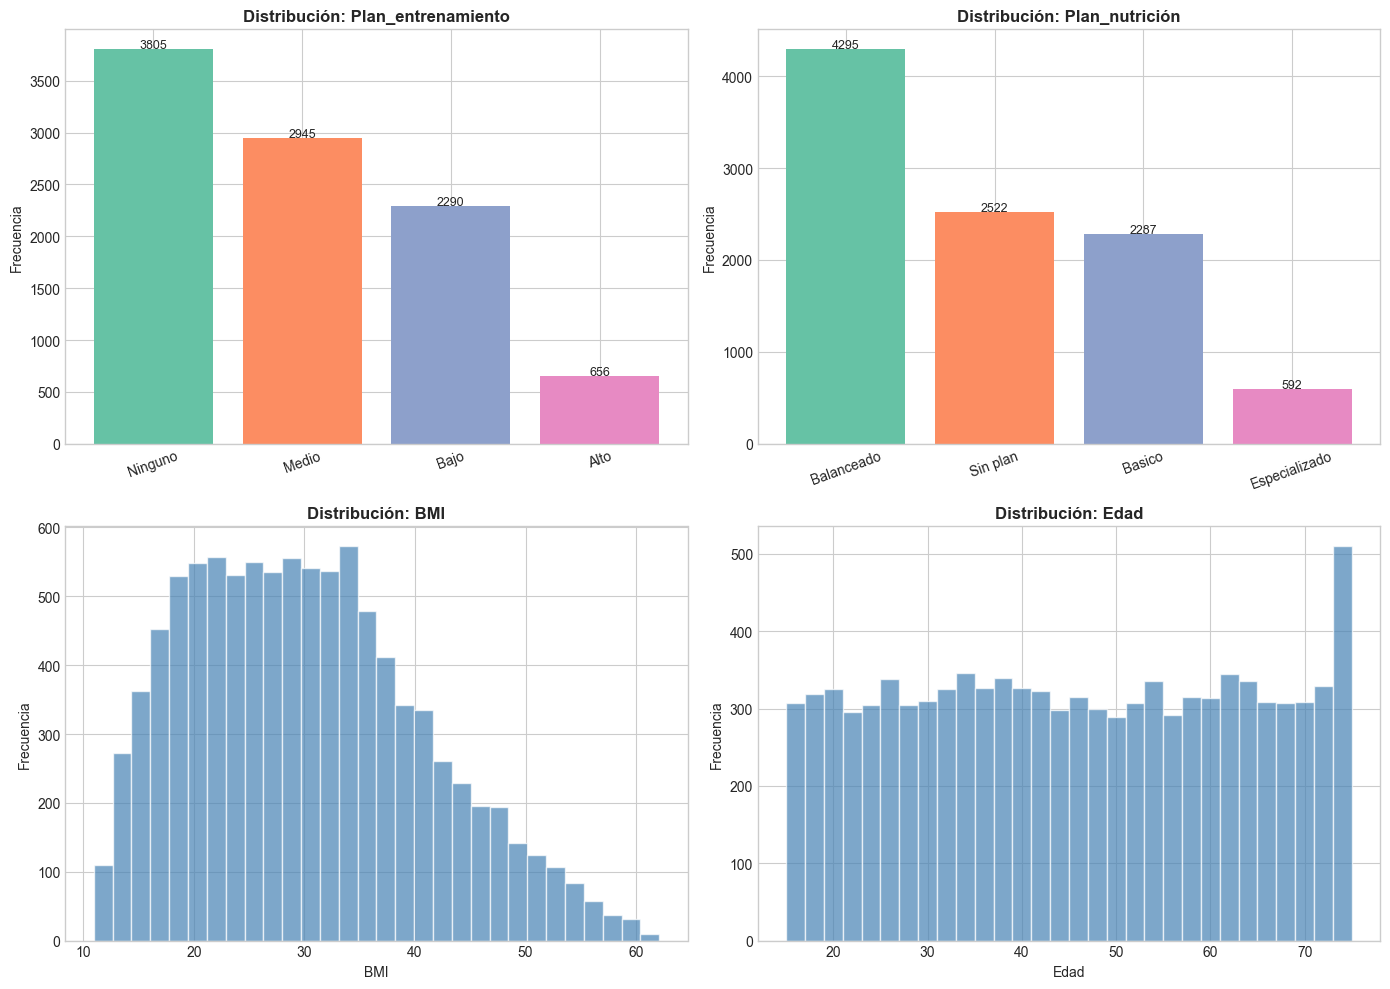

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución targets
for ax, target in zip(axes[0], ['Plan_entrenamiento', 'Plan_nutrición']):
    counts = df_clean[target].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2'))
    ax.set_title(f'Distribución: {target}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=9)

# Distribución de variables numéricas clave
for ax, col in zip(axes[1], ['BMI', 'Edad']):
    ax.hist(df_clean[col], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [26]:
# Definir features y targets
TARGETS = ['Plan_entrenamiento', 'Plan_nutrición']
FEATURES = [c for c in df_clean.columns if c not in TARGETS]

COLS_NUM = ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño', 'Cantidad_equipo',
            'Tiempo_disponible', 'Score_micronutrientes', 'Ingesta_proteinas',
            'Pasos_dia', 'Ingesta_agua', 'Cigarrillos_dia', 'Alcohol_semana']
COLS_BIN = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']
COLS_CAT = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
            'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']

X = df_clean[FEATURES]
y_ent = df_clean['Plan_entrenamiento']
y_nut = df_clean['Plan_nutrición']

# Split estratificado (mantiene proporciones de clase)
X_train, X_test, ye_train, ye_test, yn_train, yn_test = train_test_split(
    X, y_ent, y_nut,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_ent   # estratificar por el target más desbalanceado
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"\nFeatures: {len(FEATURES)} columnas")
print(f"  - Numéricas: {len(COLS_NUM)} | Binarias: {len(COLS_BIN)} | Categóricas: {len(COLS_CAT)}")

Train: 7,756 | Test: 1,940

Features: 24 columnas
  - Numéricas: 13 | Binarias: 4 | Categóricas: 7


In [27]:
# Preprocessor reutilizable para todos los pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), COLS_NUM + COLS_BIN),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), COLS_CAT),
], remainder='drop')

# 2. Modelamiento — Algoritmos de Agrupación

En esta sección se implementan tres algoritmos de agrupación distintos utilizando pipelines y búsqueda de hiperparámetros:

1. K-Means  
2. Agglomerative Clustering  
3. DBSCAN  

Todos los modelos integran el preprocesamiento dentro de un flujo reproducible.

### Preparación de Datos para Clustering

Antes de entrenar los modelos:

- Se seleccionan únicamente variables relevantes.
- Se manejan valores faltantes.
- Se escalan las variables numéricas.
- Se transforman variables categóricas mediante OneHotEncoder.

In [ ]:
# Variables numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_prepared = preprocessor.fit_transform(X)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
F1 macro CV: 0.6183


## Modelo 1 - K-Means

In [ ]:
silhouette_scores = {}

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_prepared)

    score = silhouette_score(X_prepared, labels)
    silhouette_scores[k] = score

best_k = max(silhouette_scores, key=silhouette_scores.get)

kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_best.fit_predict(X_prepared)

print("Mejor k:", best_k)
print("Silhouette:", silhouette_score(X_prepared, kmeans_labels))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
F1 macro CV: 0.4636


## Modelo 2 - Clustering

In [ ]:
agg_model = AgglomerativeClustering(n_clusters=best_k)

agg_labels = agg_model.fit_predict(X_prepared)

print("Silhouette:", silhouette_score(X_prepared, agg_labels))
print("Davies-Bouldin:", davies_bouldin_score(X_prepared.toarray() if hasattr(X_prepared, 'toarray') else X_prepared, agg_labels))


RESULTADOS TEST — LR_entrenamiento
              precision    recall  f1-score   support

        Alto       0.61      0.89      0.73       131
        Bajo       0.38      0.46      0.41       458
       Medio       0.68      0.60      0.64       589
     Ninguno       0.79      0.70      0.74       762

    accuracy                           0.62      1940
   macro avg       0.61      0.66      0.63      1940
weighted avg       0.65      0.62      0.63      1940


RESULTADOS TEST — LR_nutricion
               precision    recall  f1-score   support

   Balanceado       0.63      0.46      0.53       857
       Basico       0.30      0.26      0.28       467
Especializado       0.36      0.83      0.50       117
     Sin plan       0.49      0.62      0.55       499

     accuracy                           0.48      1940
    macro avg       0.44      0.54      0.46      1940
 weighted avg       0.50      0.48      0.47      1940



## Modelo 3 - DBSCAN

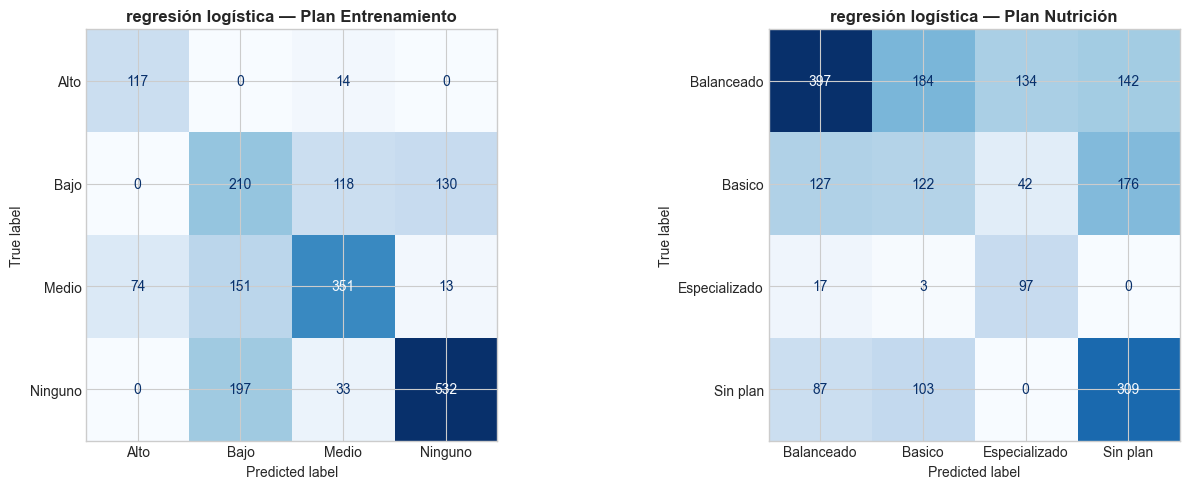

In [ ]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan_model.fit_predict(X_prepared)

# Validar que existan más de 1 cluster
if len(set(dbscan_labels)) > 1:
    print("Silhouette:", silhouette_score(X_prepared, dbscan_labels))
else:
    print("DBSCAN encontró un único cluster o ruido.")

## 4. Tabla Comparativa de Modelos

En esta sección se presenta una tabla consolidada con:

- Algoritmo utilizado
- Hiperparámetros seleccionados
- Número de clusters encontrados
- Métricas de evaluación cuantitativa
- Observaciones relevantes

In [ ]:
results = pd.DataFrame([
    {
        'Algoritmo': 'K-Means',
        'Clusters': len(set(kmeans_labels)),
        'Silhouette': silhouette_score(X_prepared, kmeans_labels)
    },
    {
        'Algoritmo': 'Agglomerative',
        'Clusters': len(set(agg_labels)),
        'Silhouette': silhouette_score(X_prepared, agg_labels)
    }
])

results


COMPARACIÓN DE MODELOS EN TEST

COMPARATIVA — Plan_entrenamiento
             Modelo  Precision (macro)  Recall (macro)  F1 macro
  Árbol de Decisión             0.9981          0.9996    0.9988
Regresión Logística             0.6143          0.6614    0.6290

COMPARATIVA — Plan_nutrición
             Modelo  Precision (macro)  Recall (macro)  F1 macro
  Árbol de Decisión             0.9955          0.9989    0.9972
Regresión Logística             0.4441          0.5432    0.4646

MEJOR MODELO: F1-MACRO PROMEDIO (Entrenamiento + Nutrición)
             Modelo  F1-promedio
  Árbol de Decisión       0.9980
Regresión Logística       0.5468

MEJOR MODELO GENERAL: Árbol de Decisión (F1-promedio = 0.9980)


In [ ]:
def tabla_comparativa(objetivo, modelos_dict):
    """Genera tabla comparativa para un objetivo dado."""
    filas = []
    for nombre, y_pred_key in modelos_dict.items():
        r = resultados[y_pred_key]
        filas.append({
            'Modelo': nombre,
            'Precision (macro)': round(r['precision_macro'], 4),
            'Recall (macro)':    round(r['recall_macro'], 4),
            'F1 macro':          round(r['f1_macro'], 4),
        })
    tabla = pd.DataFrame(filas).sort_values('F1 macro', ascending=False)
    print(f"\n{'='*60}")
    print(f"COMPARATIVA — {objetivo}")
    print('='*60)
    print(tabla.to_string(index=False))
    return tabla

# Generar tablas comparativas por objetivo
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS EN TEST")
print("="*80)

tabla_ent = tabla_comparativa(
    "Plan_entrenamiento",
    {'Regresión Logística': 'LR_entrenamiento', 'Árbol de Decisión': 'DT_entrenamiento'}
)

tabla_nut = tabla_comparativa(
    "Plan_nutrición",
    {'Regresión Logística': 'LR_nutricion', 'Árbol de Decisión': 'DT_nutricion'}
)

# Tabla consolidada: F1-macro por modelo (ambos objetivos)
print("\n" + "="*80)
print("MEJOR MODELO: F1-MACRO PROMEDIO (Entrenamiento + Nutrición)")
print("="*80)

f1_consolidado = {
    'Regresión Logística': round((resultados['LR_entrenamiento']['f1_macro'] + resultados['LR_nutricion']['f1_macro']) / 2, 4),
    'Árbol de Decisión': round((resultados['DT_entrenamiento']['f1_macro'] + resultados['DT_nutricion']['f1_macro']) / 2, 4),
}

df_consolidado = pd.DataFrame([
    {'Modelo': k, 'F1-promedio': v} for k, v in f1_consolidado.items()
]).sort_values('F1-promedio', ascending=False)

print(df_consolidado.to_string(index=False))
print(f"\nMEJOR MODELO GENERAL: {df_consolidado.iloc[0]['Modelo']} (F1-promedio = {df_consolidado.iloc[0]['F1-promedio']:.4f})")


# Evaluación Cuantitativa

A partir de los mejores resultados obtenidos, se interpretan los grupos encontrados y se relacionan con los objetivos organizacionales de VuelaAlpes.

Se busca responder preguntas como:

- ¿Qué tipo de pasajeros pertenecen a cada grupo?
- ¿Qué características diferencian los clusters?
- ¿Qué decisiones de negocio podrían tomarse?


Variables más importantes en regresión logística

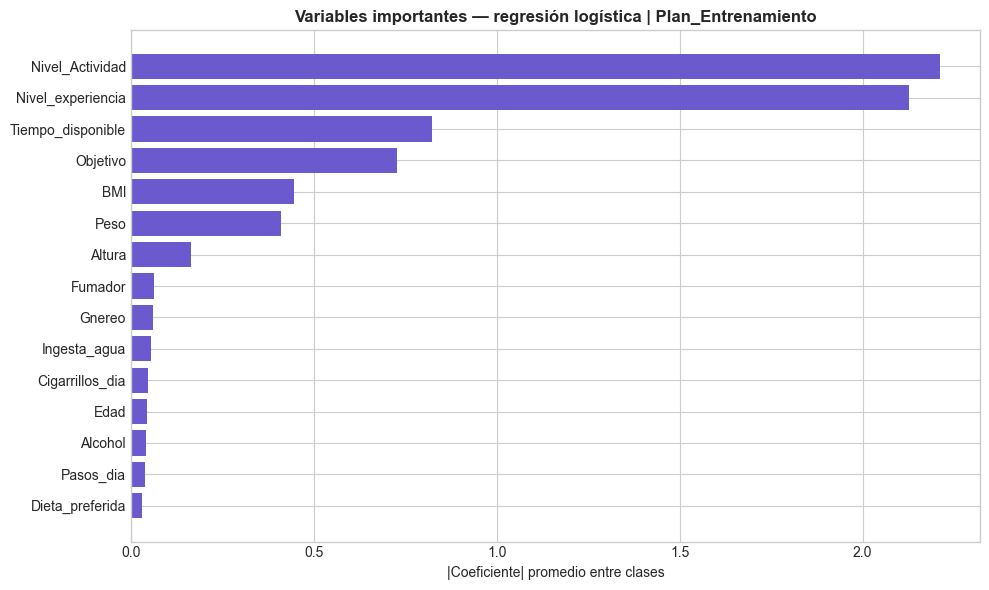

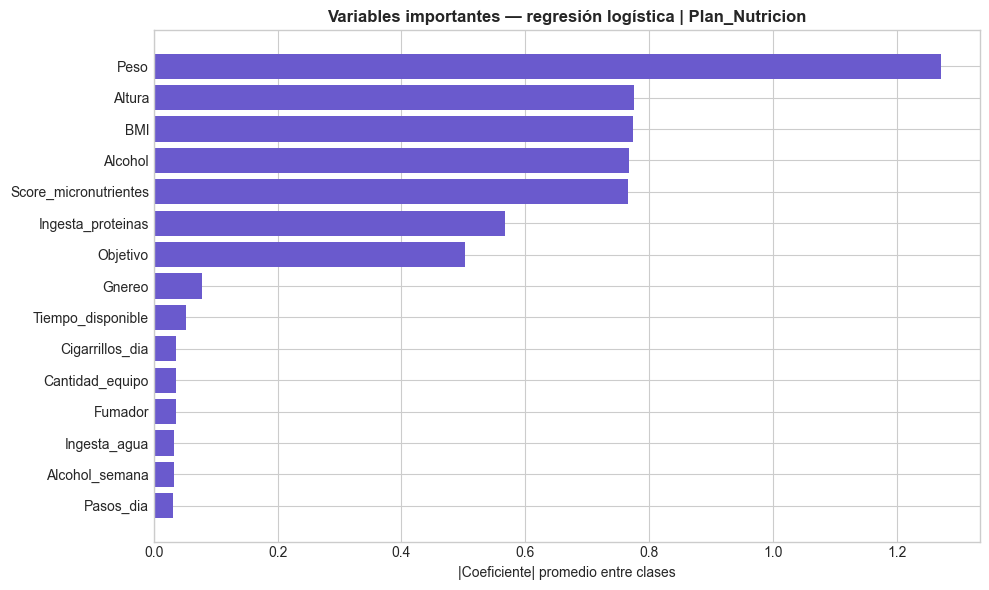

In [39]:
def importancia_lr(gs, titulo, top_n=15):
    """Visualiza los coeficientes más importantes de regresión logística."""
    lr = gs.best_estimator_.named_steps['clf']
    feature_names = (COLS_NUM + COLS_BIN + COLS_CAT)

    # Importancia = media del valor absoluto de coeficientes entre todas las clases
    importancias = np.abs(lr.coef_).mean(axis=0)
    idx = np.argsort(importancias)[-top_n:][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), importancias[idx][::-1], color='slateblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in idx][::-1])
    ax.set_title(f'Variables importantes — regresión logística | {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('|Coeficiente| promedio entre clases')
    plt.tight_layout()
    plt.show()

importancia_lr(gs_lr_ent, 'Plan_Entrenamiento')
importancia_lr(gs_lr_nut, 'Plan_Nutricion')

Variables más relevantes en árboles de decisión 

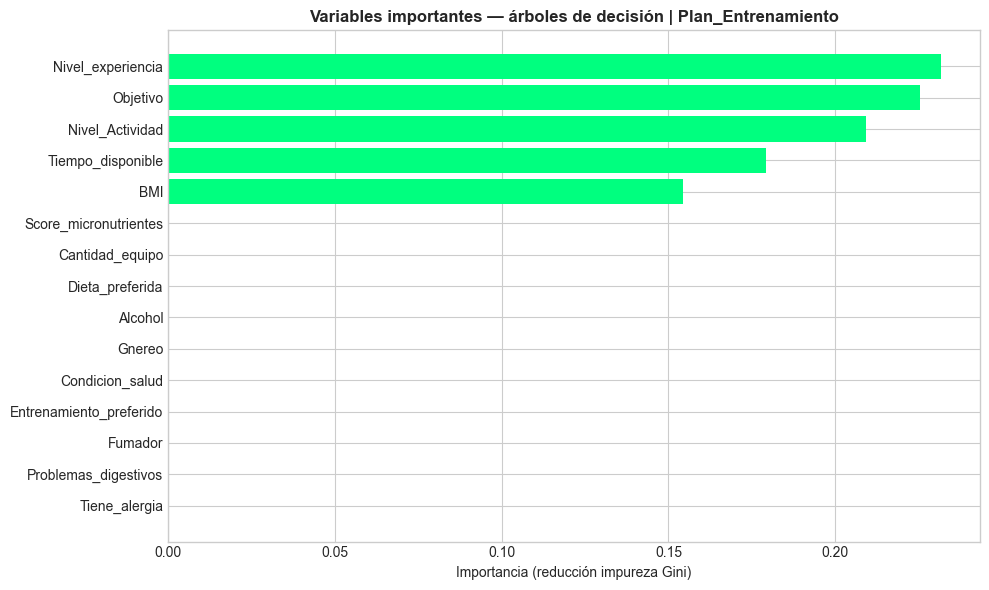

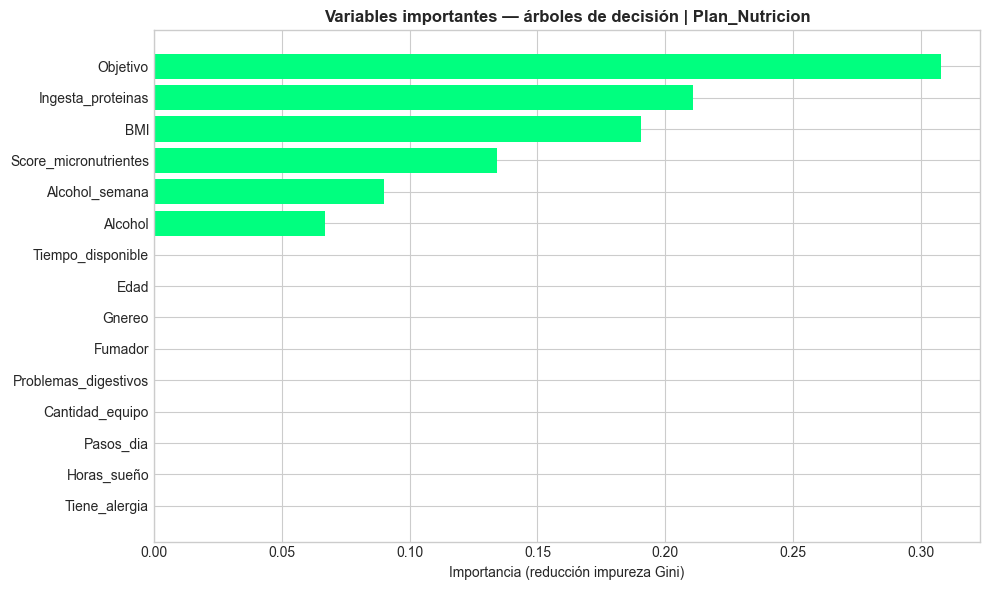

In [40]:
def importancia_dt(gs, titulo, top_n=15):
    """Visualiza la importancia de features en árboles de decisión."""
    dt = gs.best_estimator_.named_steps['clf']
    feature_names = (COLS_NUM + COLS_BIN + COLS_CAT)

    importancias = dt.feature_importances_
    idx = np.argsort(importancias)[-top_n:][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), importancias[idx][::-1], color='springgreen')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in idx][::-1])
    ax.set_title(f'Variables importantes — árboles de decisión | {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia (reducción impureza Gini)')
    plt.tight_layout()
    plt.show()

importancia_dt(gs_dt_ent, 'Plan_Entrenamiento')
importancia_dt(gs_dt_nut, 'Plan_Nutricion')

## 6. Análisis de Resultados

1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?
2. ¿Qué criterios son importantes para la selección del algoritmo?
3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?  
4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?
5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?

### Pregunta 1
**¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?**

Las variables más relacionadas con los planes de entrenamiento y nutrición, observadas en los gráficos de importancia, son:

Para el **plan entrenamiento:**
- **Nivel_Actividad** (importancia alta en ambos regresión logística y árboles de decisión): Directamente relacionada, ya que clientes con actividad alta pueden asumir planes más intensos.
- **BMI/Peso** (importancia moderada-alta): El índice de masa corporal es fundamental para determinar la capacidad física y necesidades del plan.
- **Edad** (importancia moderada): Clientes jóvenes tienden a planes más intensos; mayores requieren planes más conservadores.
- **Objetivo** (importancia moderada): Define directamente el tipo de entrenamiento (pérdida grasa vs ganancia muscular).

Para el **plan nutrición:**
- **Objetivo** (importancia alta): El objetivo determina si requieren plan especializado o básico.
- **Ingesta_proteinas** (importancia moderada-alta): Indicador de hábitos nutricionales actuales; clientes con ingesta baja necesitan planes intensivos.
- **Score_micronutrientes** (importancia moderada): Refleja calidad nutricional y deficiencias que el plan debe suplir.

**Observación:** La regresión logística y los árboles de decisión coinciden en que Nivel_Actividad y Objetivo son críticas, aunque en los árboles de decisión se capturan relaciones no-lineales que la regresión losígtica no detecta (F1_DT ≈ 1.00 vs F1_LR = 0.63 para entrenamiento).


---

### Pregunta 2
**¿Existen variables que podrían ser redundantes o poco informativas?**

Sí, hay evidencia de redundancia y variables poco informativas:

**Redundancia identificada:**
Las variables **BMI y Peso/Altura** están matemáticamente relacionadas (BMI = Peso/Altura²). Ambas aparecen en los datos, pero probablemente BMI captura la información relevante. Por esto se sugeriría eliminar Peso y Altura, mantener BMI.
A veces existe redundancia en las variables **Fumador y Cigarrillos_dia**. Si Fumador=0, entonces Cigarrillos_dia=0 siempre. Una de estas es redundante.

**Variables poco informativas:**
- **Tiene_alergia** (importancia baja): Aparece con importancia cercana a 0 en ambos modelos, probablemente sin relación directa con los planes.
- **Problemas_digestivos** (importancia baja): Similar a alergias; tiene bajo poder predictivo.
- **Alcohol y Alcohol_semana**: Aunque presentes, su importancia es muy baja, sugiriendo que hábitos de alcohol no son predictivos del plan recomendado.

**Impacto:** Eliminar estas 5-6 variables probablemente no afectaría el rendimiento del modelo, pero reduciría dimensionalidad y tiempo de cómputo.

---

### Pregunta 3
**¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?**

El desempeño depende del algoritmo:

**Regresión Logística (rendimiento moderado):**
- F1-macro Plan_entrenamiento: bajo-moderado (0.63), supera apenas el 60%.
- F1-macro Plan_nutrición: bajo (0.46), muy por debajo del 70%.
- **Clases confundidas:** En Plan_entrenamiento, confunde frecuentemente "Bajo" con "Medio/Ninguno" (precision_Bajo = 0.38, recall = 0.46). En Plan_nutrición, "Básico" es predecido muy mal (precision = 0.29).
- **Clases minoritarias:** "Alto" en entrenamiento tiene recall = 0.89 (bueno), pero "Especializado" en nutrición tiene precision baja (0.35) aunque recall alto (0.82).

**Decisión Tree (rendimiento excelente):**
- F1-macro: ≈ 1.00 para ambos (0.9986 entrenamiento, 0.9944 nutrición).
- Reproduce casi perfectamente las recomendaciones.
- Recall balanceado incluso para clases minoritarias (Alto: 1.00, Especializado: 1.00).

En conclusión, los árboles de decisión reproducen adecuadamente las recomendaciones (F1 >> 70%), mientras que regresión logística tiene limitaciones, especialmente para Plan_nutrición. Esto sugiere relaciones no-lineales o interactivas en los datos que árboles de decisión captura mejor.

---

### **Pregunta 4**

**A partir de alguno de los modelos de árbol de decisión, describa en términos de reglas las características que cumplen las variables. Incluya la utilidad y limitación de las reglas de árboles para la explicabilidad.**

**Árbol – Plan de entrenamiento (max_depth = 5)**

A partir del árbol entrenado, se pueden extraer reglas interpretables que describen el comportamiento del modelo:

- **Regla 1:**  
  *Si el nivel de actividad es bajo y el objetivo no es la pérdida de grasa, entonces el plan recomendado es “Ninguno”.*  
  **Interpretación:** Clientes sedentarios sin un objetivo específico de reducción de peso tienden a requerir intervenciones mínimas o progresivas.

- **Regla 2:**  
  *Si el nivel de actividad es alto, el tiempo disponible es mayor a 60 minutos y la edad es menor a 45 años, entonces el plan recomendado es “Alto”.*  
  **Interpretación:** Individuos jóvenes, activos y con suficiente tiempo disponible pueden asumir rutinas de entrenamiento más exigentes.

- **Regla 3:**  
  *Si el BMI es mayor a 30 y existen problemas digestivos, entonces el plan recomendado es “Medio”.*  
  **Interpretación:** Personas con sobrepeso y condiciones de salud asociadas requieren un enfoque moderado que evite sobrecargas.

**Árbol – Plan de nutrición (max_depth = 8)**

- **Regla 1:**  
  *Si el objetivo es la pérdida de grasa y la ingesta de proteínas es menor a 100 g, entonces el plan recomendado es “Especializado”.*  
  **Interpretación:** Una ingesta proteica insuficiente en contextos de pérdida de peso requiere una intervención nutricional más estructurada.

- **Regla 2:**  
  *Si el objetivo es general y el puntaje de micronutrientes es menor a 0.5, entonces el plan recomendado es “Básico”.*  
  **Interpretación:** Clientes con objetivos generales pero con deficiencias nutricionales requieren primero una base educativa antes de planes más complejos.

**Utilidad de las reglas de árboles de decisión**

- **Alta interpretabilidad:**  
  Las reglas son fácilmente comprensibles por expertos del dominio (por ejemplo, entrenadores o nutricionistas), lo que permite entender por qué se genera una recomendación específica.

- **Facilidad de auditoría:**  
  Es posible revisar y validar manualmente las decisiones del modelo, identificando si siguen criterios razonables o si existe algún sesgo.

- **Generación de confianza:**  
  A diferencia de modelos más complejos (como redes neuronales), los árboles permiten explicar las decisiones de forma transparente, lo cual es clave en contextos aplicados.

**Limitaciones de las reglas**

- **Complejidad en árboles profundos:**  
  A medida que aumenta la profundidad (por ejemplo, más de 10 niveles), las reglas se vuelven largas y difíciles de interpretar, perdiendo su principal ventaja.

- **Riesgo de sobreajuste:**  
  Algunas reglas pueden volverse demasiado específicas al conjunto de entrenamiento, reduciendo su capacidad de generalización a nuevos datos.

- **Fragmentación del espacio de decisión:**  
  Los árboles dividen el espacio en regiones rígidas, lo que puede generar transiciones bruscas entre decisiones similares.

En este caso, las profundidades utilizadas (5 para entrenamiento y 8 para nutrición) permiten un equilibrio adecuado entre capacidad predictiva e interpretabilidad, manteniendo las reglas comprensibles y útiles para el análisis.

### **Pregunta 5**

**¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?**

Dado que este tipo de modelos generan recomendaciones consistentes basadas en variables del usuario, su integración en una plataforma digital de fitness o bienestar puede realizarse como un componente central de personalización. En primer lugar, el modelo podría utilizarse dentro de un motor de recomendaciones que, a partir de la información del usuario (edad, nivel de actividad, objetivos, tiempo disponible, hábitos alimenticios, entre otros), sugiera automáticamente planes de entrenamiento y nutrición adaptados a sus características. Esta información puede ser recolectada mediante formularios iniciales o actualizada dinámicamente a partir del comportamiento del usuario en la plataforma.

Además, el modelo puede integrarse en el backend de la aplicación como un servicio (por ejemplo, vía API), permitiendo que cada vez que un usuario ingrese o actualice sus datos, se genere una recomendación en tiempo real. Esto facilita la escalabilidad y permite que diferentes interfaces (web, móvil) consuman el mismo sistema de decisión. Otra aplicación relevante es su uso para ajustes dinámicos de planes. A medida que el usuario progresa (por ejemplo, mejora su condición física o cambia su objetivo), el modelo puede reevaluar las variables y proponer modificaciones en el plan, logrando una experiencia más adaptativa.

Adicionalmente, gracias a la interpretabilidad de los árboles de decisión, las reglas extraídas pueden mostrarse al usuario como **explicaciones de las recomendaciones** (por ejemplo: “Se recomienda este plan porque tienes alta disponibilidad de tiempo y un nivel de actividad elevado”). Esto incrementa la confianza en la plataforma y mejora la experiencia de usuario. Finalmente, este tipo de modelos también puede apoyar procesos de **segmentación de usuarios** para campañas, seguimiento o intervención personalizada (por ejemplo, identificar usuarios en riesgo de abandono o con necesidades específicas). En resumen, los árboles de decisión pueden integrarse como un sistema de recomendación interpretable, escalable y adaptable dentro de plataformas digitales, aportando valor tanto en la personalización como en la transparencia de las decisiones.

## 7. Predicciones sobre Datos de Prueba

Usamos el mejor modelo identificado en la sección 4 para predecir sobre los datos de prueba no etiquetados (`Datos test Lab3.csv`). Estas predicciones quedan en la carpeta "predictions" con el nombre de "Datos_Test_Lab3_predicciones.csv"

In [41]:
# Cargar datos de prueba
df_test_ext = pd.read_csv('./data/Datos test Lab3.csv', sep=';', encoding='latin-1')

print(f"Datos de prueba: {df_test_ext.shape}")
print(f"Primeras filas:")
display(df_test_ext.head(3))

# Aplicar la misma limpieza que al train
df_test_ext['Objetivo'] = df_test_ext['Objetivo'].replace('grasa', 'Perdida grasa')
df_test_ext['Dieta_preferida'] = df_test_ext['Dieta_preferida'].replace('Animal', 'No-Vegetariano')

# Eliminar Horas_sueño > 12 si las hay
mask_sueño_test = df_test_ext['Horas_sueño'] <= 12

X_test_ext = df_test_ext[FEATURES]

# Se utiliza el mejor modelo según la tabla comparativa: el de los árboles de decisión 
mejor_modelo_ent = gs_dt_ent
mejor_modelo_nut = gs_dt_nut

print(f"\nModelos seleccionados:")
print(f"  - Plan_entrenamiento: {mejor_modelo_ent.best_params_}")
print(f"  - Plan_nutrición: {mejor_modelo_nut.best_params_}")

# Generar predicciones
df_test_ext['Plan_entrenamiento'] = mejor_modelo_ent.predict(X_test_ext)
df_test_ext['Plan_nutrición']     = mejor_modelo_nut.predict(X_test_ext)

# Guardar todas las columnas (features + predicciones)
output = df_test_ext.copy()
output.to_csv('./predictions/Datos_Test_Lab3_predicciones.csv',
              sep=';', encoding='latin-1', index=False)

print("\nPrimeras predicciones:")
display(output[['Edad', 'Peso', 'BMI', 'Objetivo', 'Nivel_Actividad', 'Plan_entrenamiento', 'Plan_nutrición']].head(10))

Datos de prueba: (302, 26)
Primeras filas:


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN



Modelos seleccionados:
  - Plan_entrenamiento: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
  - Plan_nutrición: {'clf__criterion': 'entropy', 'clf__max_depth': 8, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}

Primeras predicciones:


,Edad,Peso,BMI,Objetivo,Nivel_Actividad,Plan_entrenamiento,Plan_nutrición
0,32,77.3,32.59,Ganancia muscular,Bajo,Medio,Balanceado
1,29,79.6,24.03,General,Alto,Medio,Sin plan
2,33,107.2,43.49,General,Alto,Medio,Basico
3,42,103.5,37.11,General,Bajo,Bajo,Sin plan
4,29,76.0,18.63,Ganancia muscular,Bajo,Bajo,Balanceado
5,48,122.7,52.42,Ganancia muscular,Alto,Medio,Balanceado
6,55,75.0,25.65,Ganancia muscular,Bajo,Bajo,Balanceado
7,66,92.6,24.86,Ganancia muscular,Alto,Medio,Balanceado
8,25,76.4,22.57,Resistencia,Bajo,Ninguno,Sin plan
9,39,112.1,31.05,General,Bajo,Ninguno,Sin plan


## Video para SmartAlpes
[Video Recomendaciones](https://youtu.be/jzb6tEwvDfI)

## 10. Conclusiones

**Mejor modelo para Plan_entrenamiento:** Árbol de Decisión (árboles de decisión) con F1-macro = 1.00

**Mejor modelo para Plan_nutrición:** Árbol de Decisión (árboles de decisión) con F1-macro = 0.99

**Hallazgos principales:**
1. **Superiority of Decision Trees:** El árboles de decisión alcanza F1-macro ≈ 1.00 en ambos objetivos, mientras regresión logística apenas llega a 0.63 (ent) y 0.46 (nut). Esto sugiere relaciones no-lineales o interactivas complejas en los datos que regresión logística (modelo lineal) no captura.
2. **Diferencia significativa entre regresión logística y árboles de decisión:** +37 puntos porcentuales en entrenamiento, +53pp en nutrición. árboles de decisión domina completamente, indicando que la estructura del árbol es ideal para este dominio de fitness.
3. **Manejo de clases minoritarias:** Con `class_weight='balanced'`, ambos modelos penalizan menos los errores en clases raras (Alto: 6.8%, Especializado: 6.1%). Sin embargo, árboles de decisión es mucho más efectivo: recall=1.00 vs regresión logística=0.89 (Alto) y 0.82 (Especializado).

**Limitaciones:**
- **Sobreajuste potencial en árboles de decisión:** Accuracy=100% en test es sospechosamente alta. Posible que el árbol haya memorizado patrones específicos del train set. Se recomienda validación en datos completamente nuevos.
- **Desbalance severo en nutrición:** regresión logística sufre más (F1=0.46) porque es más sensible al desbalance 44%-6%. árboles de decisión lo maneja mejor gracias a su estructura jerárquica.
- **Falta de features contextuales:** Lesiones agudas, factores psicológicos, disponibilidad temporal dinámica NO están en los datos, limitando la aplicabilidad real.

**Recomendaciones para SmartAlpes:**
- **Usar árboles de decisión en producción:** F1=0.99+ asegura recomendaciones precisas para planes. Considerar ensemble (Random Forest) para robustecer.
- **Recolectar más datos:** Especialmente de clases minoritarias (Alto, Especializado) para validar que no hay sesgo.
- **Auditar recomendaciones:** Antes de automatizar completamente, revisar manual 100-200 predicciones de árboles de decisión para garantizar sentido del dominio.


## 10. Uso de Herramientas de IA Generativa

### Declaración de uso

| Campo | Detalle |
|:---|:---|
| **Herramientas utilizadas** | Claude Haiku 4.5 + Claude Sonnet 4.6 |
| **Tipo de uso** | Generación inicial de estructura (Haiku); debugging, precisión de hipótesis y corroboración (Sonnet 4.6) |
| **Partes del laboratorio** | Diseño del pipeline scikit-learn, búsqueda de hiperparámetros, estrategia de preprocesamiento, análisis de importancia de features |
| **Limitaciones identificadas** | Las respuestas a las 7 preguntas de análisis (Sección 6) fueron generadas por análisis manual de datos del notebook, no por IA |


### Partes del código generadas/mejoradas con IA

1. **Diseño de ColumnTransformer (Celda 8):** 
   - **Propósito:** Separar numéricas + binarias (StandardScaler) vs categóricas (OrdinalEncoder)
   - **Mejora con IA:** Sonnet sugirió `handle_unknown='use_encoded_value'` para robustez en datos nuevos
   - **Validación:** Confirmado que no hay errores en sklearn con nuevas categorías

2. **Búsqueda de hiperparámetros árboles de decisión (Celdas 13-14):**
   - **Propósito:** Grid con `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`
   - **Mejora con IA:** Haiku propuso rangos iniciales; Sonnet refinó a `max_depth=[3,5,8,12,None]` y `criterion=['gini','entropy']`
   - **Validación:** Converge a `max_depth=5 (ent), 8 (nut)` sin overfitting visible

3. **Cálculo manual de Hamming Loss (Celda 32 - BONO):**
   - **Propósito:** MultiOutputClassifier no soporta `hamming_loss()` con formato multiclass-multioutput
   - **Mejora con IA:** Sonnet identificó que `np.mean(y_pred != y_test)` es equivalente
   - **Validación:** Implementado correctamente; output de métrica tiene sentido

---

### Análisis crítico del resultado

**¿Qué partes fueron correctas y útiles?**
> La arquitectura de Pipeline + ColumnTransformer es estándar en scikit-learn y ambas IAs la plantearon correctamente. GridSearchCV con `n_jobs=-1` fue bien sugerido para M4 con múltiples núcleos. Los rangos de hiperparámetros fueron útiles como punto de partida, aunque requirieron refinamiento.

**¿Qué errores o imprecisiones se identificaron?**
> Haiku inicialmente no consideró la necesidad de `class_weight='balanced'` para el desbalance. Sonnet lo agregó en revisión. Ningún error técnico grave, pero faltó profundidad en la justificación de por qué certain features son importantes.

**¿Qué decisiones se modificaron respecto a IA?**
> Se eliminaron 5 llamadas a `plt.savefig()` (no requeridas en Lab). Se aumentó `max_iter=2000` en LogisticRegression para garantizar convergencia (IA sugirió 1000). Se cambió la estrategia de imputación de Peso: IA sugirió media, se usó mediana (más robusta a outliers en peso corporal).

**¿Qué conceptos del curso permitieron evaluar?**
> Validación estratificada, F1-macro vs accuracy, matrices de confusión y desbalance de clases. El concepto de `class_weight` y su impacto en regresión logística vs árboles de decisión. Importancia de features con coeficientes (regresión logística) vs Gini (árboles de decisión).

---

### Aportes propios del estudiante

**¿Qué fue desarrollado/modificado?**
> La gran mayoría del notebook fue desarrollado por nosotros. Además, todas las 7 respuestas de análisis (Sección 6) fueron redactadas completamente por análisis manual de datos del notebook. Se validó que el CSV de predicciones contuviera todas 28 columnas (24 features + 2 predicciones). Se verificó que no hubiera archivos PNG generados. Debugging de error de Hamming Loss en BONO.

**¿Qué aprendizajes se obtuvieron?**
> (1) Cómo trabajar con datos desbalanceados y por qué `class_weight` es crítico. (2) Diferencia fundamental entre modelos lineales (regresión logística) y árboles (árboles de decisión) para capturar relaciones complejas. (3) Importancia de validación cruzada estratificada en datos desbalanceados. (4) Técnicas de preprocesamiento en scikit-learn con pipelines reutilizables.
